# D01: Data Quality & Exploratory Data Analysis

Spec: `docs/member1_guide.md`

## Setup & Imports

In [1]:
import hashlib, json, os, re, subprocess, sys, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")

ROOT = Path().resolve()
while not (ROOT/"data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RAW_CSV  = ROOT/"data"/"raw"/"news_articles.csv"
RES_DQ   = ROOT/"results"/"data_quality"
FIG_DIR  = RES_DQ/"figures"
INTERIM  = ROOT/"data"/"interim"
for d in [RES_DQ, FIG_DIR, INTERIM]:
    d.mkdir(parents=True, exist_ok=True)

REQUIRED_COLS = ["article_id","title","content","published_at","source","url","category_gold"]
VALID_SOURCES = {"vnexpress","tuoitre","vietnamnet"}
VALID_CATS = {"Kinh doanh","Khoa học công nghệ","Thể thao",
              "Giáo dục","Sức khỏe","Pháp luật","Giải trí"}
DPI = 300
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.family': 'Segoe UI', 'axes.unicode_minus': False})
print("Setup complete. ROOT =", ROOT)

Setup complete. ROOT = D:\HK5\NLP\NLP_Project\vietnamese-news-topic-discovery


## §5.1 Chuẩn bị & Chụp Snapshot Dữ liệu Gốc

In [2]:
sha256 = hashlib.sha256(RAW_CSV.read_bytes()).hexdigest()
file_size_bytes = RAW_CSV.stat().st_size
df = pd.read_csv(RAW_CSV,
    dtype={c: str for c in ["article_id","url","title","content","source","category_gold"]},
    low_memory=False)
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
try:
    git_commit = subprocess.check_output(
        ["git","log","--follow","-1","--format=%H", str(RAW_CSV)],
        cwd=str(ROOT), stderr=subprocess.DEVNULL).decode().strip() or "N/A"
except:
    git_commit = "N/A"
print(f"Rows: {df.shape[0]:,} | Cols: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")
print(f"Size: {file_size_bytes/1_048_576:.2f} MB | SHA256: {sha256[:24]}...")
print(f"Git commit: {git_commit}")

Rows: 9,304 | Cols: 7
Columns: ['article_id', 'title', 'content', 'published_at', 'source', 'url', 'category_gold']
Size: 40.54 MB | SHA256: 548b35953368857373e8f266...
Git commit: 5c215c0130e00c7f80ffad021a7838fdd2ddc373


In [3]:
snapshot = {"file": str(RAW_CSV.relative_to(ROOT)), "sha256": sha256,
    "size_bytes": file_size_bytes, "n_rows": int(df.shape[0]), "n_cols": int(df.shape[1]),
    "columns": df.columns.tolist(), "dtypes": {c: str(t) for c, t in df.dtypes.items()},
    "git_commit": git_commit,
    "head_5": df.head(5)[["article_id","source","category_gold","published_at"]].astype(str).to_dict(orient="records"),
    "tail_5": df.tail(5)[["article_id","source","category_gold","published_at"]].astype(str).to_dict(orient="records")}
snap_path = RES_DQ/"raw_snapshot.json"
snap_path.write_text(json.dumps(snapshot, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", snap_path.relative_to(ROOT))

Saved: results\data_quality\raw_snapshot.json


In [4]:
display(df[["article_id","source","category_gold","published_at","url"]].head())
display(df[["article_id","source","category_gold","published_at","url"]].tail())
display(df.dtypes.to_frame("dtype"))

,article_id,source,category_gold,published_at,url
0,VNE_2abfa785dfe1,vnexpress,Giải trí,2026-09-01 00:00:00+07:00,https://vnexpress.net/su-nghiep-van-chuong-cua...
1,VNE_2c70cf04fe9b,vnexpress,Giáo dục,2026-09-01 00:02:00+07:00,https://vnexpress.net/cuoc-chien-cua-ky-su-goo...
2,VNE_93e812f89078,vnexpress,Giải trí,2026-09-01 00:30:05+07:00,https://vnexpress.net/duong-pho-ha-noi-cuoi-th...
3,TTR_4ae866118ba3,tuoitre,Thể thao,2026-09-01 00:32:00+07:00,https://tuoitre.vn/lien-doan-bong-da-argentina...
4,TTR_bea4a49add27,tuoitre,Giải trí,2026-09-01 00:36:00+07:00,https://tuoitre.vn/nam-than-man-anh-nhan-phuc-...


,article_id,source,category_gold,published_at,url
9299,TTR_70ea67be1dd4,tuoitre,Kinh doanh,2026-09-30 22:12:00+07:00,https://tuoitre.vn/chinh-phu-dong-y-tiep-tuc-k...
9300,TTR_9851f832246d,tuoitre,Thể thao,2026-09-30 22:18:00+07:00,https://tuoitre.vn/danh-bai-10-nguoi-brunei-tu...
9301,VNE_77a5c5c0691e,vnexpress,Thể thao,2026-09-30 23:01:15+07:00,https://vnexpress.net/djokovic-noi-dai-mach-to...
9302,VNE_bb65accb980d,vnexpress,Pháp luật,2026-09-30 23:09:31+07:00,https://vnexpress.net/cuu-tong-giam-doc-do-hop...
9303,VNE_1b97b40a8a4b,vnexpress,Khoa học công nghệ,2026-09-30 23:58:00+07:00,https://vnexpress.net/thu-nghiem-truyen-dien-k...


,dtype
article_id,object
title,object
content,object
published_at,"datetime64[ns, UTC+07:00]"
source,object
url,object
category_gold,object


## §5.2 EDA Tầng 1: Schema & Tính Hợp lệ

In [5]:
issues = []; quality_rows = []; early_stop = False
def qrow(check, measurement, value, status, note=""):
    quality_rows.append({"check": check, "measurement": measurement,
                          "value": str(value), "status": status, "note": note})

cols_actual = df.columns.tolist()
cols_match  = cols_actual == REQUIRED_COLS
qrow("schema", "column_order_match", cols_actual, "PASS" if cols_match else "FAIL",
     "" if cols_match else f"Expected {REQUIRED_COLS}")
print(f"Schema match: {'PASS' if cols_match else 'FAIL'}")
if not cols_match: early_stop = True

Schema match: PASS


In [6]:
id_null  = int(df["article_id"].isna().sum())
id_blank = int((df["article_id"].str.strip() == "").sum())
id_dup   = int(df["article_id"].duplicated().sum())
qrow("article_id.null", "isna()", id_null, "PASS" if id_null==0 else "FAIL")
qrow("article_id.blank", "strip=''", id_blank, "PASS" if id_blank==0 else "FAIL")
qrow("article_id.dup", "duplicated()", id_dup, "PASS" if id_dup==0 else "FAIL")
if id_dup > 0: early_stop = True
print(f"article_id: null={id_null}  blank={id_blank}  dup={id_dup}")

title_null  = int(df["title"].isna().sum())
title_blank = int((df["title"].fillna("").str.strip() == "").sum())
df["_wc"]   = df["content"].fillna("").str.split().str.len()
content_short = int((df["_wc"] < 50).sum())
qrow("title.null", "isna()", title_null, "PASS" if title_null==0 else "WARN")
qrow("title.blank", "strip=''", title_blank, "PASS" if title_blank==0 else "WARN")
qrow("content.short", "wc<50", content_short, "PASS" if content_short==0 else "WARN")
print(f"title: null={title_null}  blank={title_blank}")
print(f"content short (<50 words): {content_short:,}")

article_id: null=0  blank=0  dup=0
title: null=0  blank=0
content short (<50 words): 0


In [7]:
parse_fail = int(df["published_at"].isna().sum())
month_ok = ((df["published_at"].dt.year==2026) & (df["published_at"].dt.month==9)).all() if parse_fail==0 else False
qrow("published_at.parse_fail","coerce NaT",parse_fail,"PASS" if parse_fail==0 else "FAIL")
qrow("published_at.month_2609","year=2026 month=9",str(month_ok),"PASS" if month_ok else "WARN")
if parse_fail > 0: early_stop = True
print(f"published_at: parse_fail={parse_fail}  all_sept2026={month_ok}")

src_vals  = set(df["source"].dropna().unique())
src_extra = src_vals - VALID_SOURCES
qrow("source.valid_set","unique()",sorted(src_vals),"PASS" if not src_extra else "FAIL",
     f"extra={src_extra}" if src_extra else "")
if src_extra: early_stop = True
print(f"source unique: {sorted(src_vals)}  extra: {src_extra}")

url_null    = int(df["url"].isna().sum())
url_dup     = int(df["url"].duplicated().sum())
url_invalid = int((~df["url"].fillna("").str.match(r"^https?://")).sum())
qrow("url.null","isna()",url_null,"PASS" if url_null==0 else "WARN")
qrow("url.dup","duplicated()",url_dup,"PASS" if url_dup==0 else "WARN")
qrow("url.invalid_format","http(s)?",url_invalid,"PASS" if url_invalid==0 else "WARN")
print(f"url: null={url_null}  dup={url_dup}  invalid_format={url_invalid}")

cat_vals  = set(df["category_gold"].dropna().unique())
cat_extra = cat_vals - VALID_CATS
cat_null  = int(df["category_gold"].isna().sum())
cat_blank = int((df["category_gold"].fillna("").str.strip()=="").sum())
qrow("category_gold.null","isna()",cat_null,"PASS" if cat_null==0 else "FAIL")
qrow("category_gold.blank","strip=''",cat_blank,"PASS" if cat_blank==0 else "FAIL")
qrow("category_gold.valid_set","unique()",sorted(cat_vals),"PASS" if not cat_extra else "FAIL",
     f"extra={cat_extra}" if cat_extra else "")
if cat_extra or cat_null > 0: early_stop = True
print(f"category unique: {sorted(cat_vals)}")
print(f"\n{'=== EARLY STOP ===' if early_stop else '=== All blocking checks passed ==='}")

published_at: parse_fail=0  all_sept2026=True
source unique: ['tuoitre', 'vietnamnet', 'vnexpress']  extra: set()
url: null=0  dup=0  invalid_format=0
category unique: ['Giáo dục', 'Giải trí', 'Khoa học công nghệ', 'Kinh doanh', 'Pháp luật', 'Sức khỏe', 'Thể thao']

=== All blocking checks passed ===


## §5.3 EDA Tầng 2: Phân bố & Độ Bao phủ

In [8]:
df["_title_wc"]   = df["title"].fillna("").str.split().str.len()
df["_title_cc"]   = df["title"].fillna("").str.len()
df["_content_cc"] = df["content"].fillna("").str.len()
src_counts = df["source"].value_counts()
src_pct    = (src_counts / len(df) * 100).round(2)
cat_counts = df["category_gold"].value_counts()
imbalance  = round(cat_counts.max() / max(cat_counts.min(), 1), 2)
crosstab   = pd.crosstab(df["source"], df["category_gold"])
df["_date"]= df["published_at"].dt.date
daily      = df.groupby("_date").size().reset_index(name="count")

print("Phân bố nguồn báo (Source):")
display(pd.DataFrame({"Số bài": src_counts, "Tỷ lệ %": src_pct}))
print(f"\nPhân bố chuyên mục (Tỷ lệ mất cân bằng = {imbalance}x):")
display(cat_counts.to_frame("Số bài"))
print("\nBảng chéo Nguồn báo × Chuyên mục:")
display(crosstab)

Phân bố nguồn báo (Source):


,Số bài,Tỷ lệ %
source,,
tuoitre,3778,40.61
vnexpress,2969,31.91
vietnamnet,2557,27.48



Phân bố chuyên mục (Tỷ lệ mất cân bằng = 2.84x):


,Số bài
category_gold,
Kinh doanh,1995
Thể thao,1959
Sức khỏe,1238
Pháp luật,1191
Giải trí,1180
Giáo dục,1039
Khoa học công nghệ,702



Bảng chéo Nguồn báo × Chuyên mục:


category_gold,Giáo dục,Giải trí,Khoa học công nghệ,Kinh doanh,Pháp luật,Sức khỏe,Thể thao
source,,,,,,,
tuoitre,555,418,103,903,551,348,900
vietnamnet,299,340,298,537,231,334,518
vnexpress,185,422,301,555,409,556,541


In [9]:
def percentiles(s, label):
    pcts = [0, 1, 5, 50, 95, 99, 100]
    vals = np.percentile(s.dropna(), pcts)
    return {f"{label}_P{p}": int(v) for p, v in zip(pcts, vals)}

len_stats = {}
for col, lbl in [("_title_wc","title_wc"),("_title_cc","title_cc"),
                  ("_wc","content_wc"),("_content_cc","content_cc")]:
    len_stats.update(percentiles(df[col], lbl))
display(pd.Series(len_stats).to_frame("Giá trị"))

,Giá trị
title_wc_P0,4
title_wc_P1,6
title_wc_P5,8
title_wc_P50,14
title_wc_P95,20
title_wc_P99,23
title_wc_P100,30
title_cc_P0,14
title_cc_P1,27
title_cc_P5,37


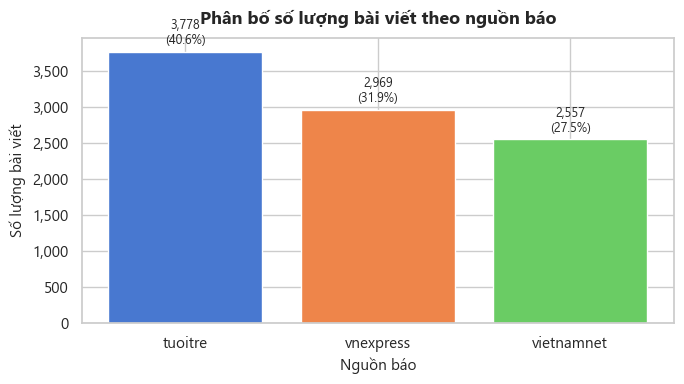

In [10]:
# Fig 1: bar_source
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(src_counts.index, src_counts.values, color=sns.color_palette("muted", len(src_counts)))
ax.bar_label(bars, labels=[f"{v:,}\n({p:.1f}%)" for v, p in zip(src_counts.values, src_pct.values)], padding=3, fontsize=9)
ax.set_title("Phân bố số lượng bài viết theo nguồn báo", fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("Nguồn báo", fontsize=11)
ax.set_ylabel("Số lượng bài viết", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "bar_source.png", dpi=DPI)
plt.show()

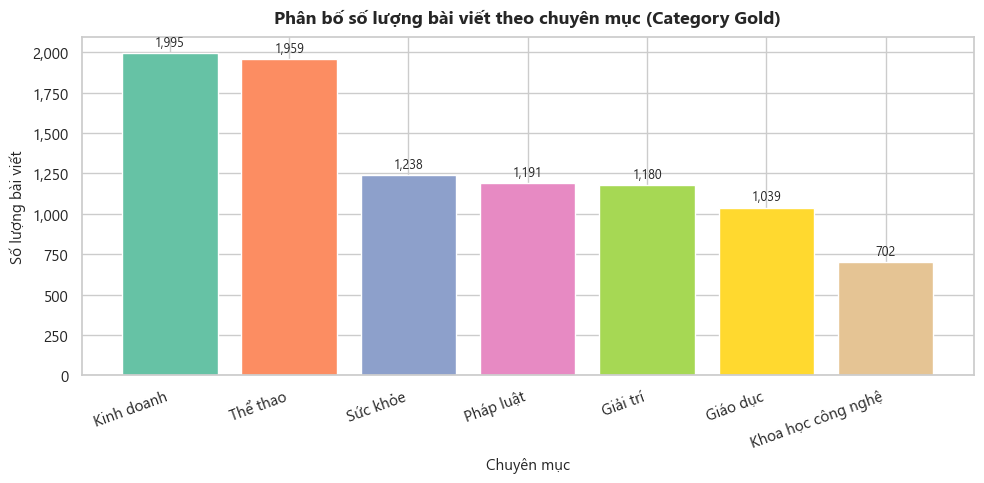

In [11]:
# Fig 2: bar_category
fig, ax = plt.subplots(figsize=(10, 5))
order = cat_counts.index.tolist()
bars = ax.bar(order, cat_counts[order].values, color=sns.color_palette("Set2", len(order)))
ax.bar_label(bars, labels=[f"{v:,}" for v in cat_counts[order].values], padding=3, fontsize=9)
ax.set_title("Phân bố số lượng bài viết theo chuyên mục (Category Gold)", fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("Chuyên mục", fontsize=11)
ax.set_ylabel("Số lượng bài viết", fontsize=11)
plt.xticks(rotation=20, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "bar_category.png", dpi=DPI)
plt.show()

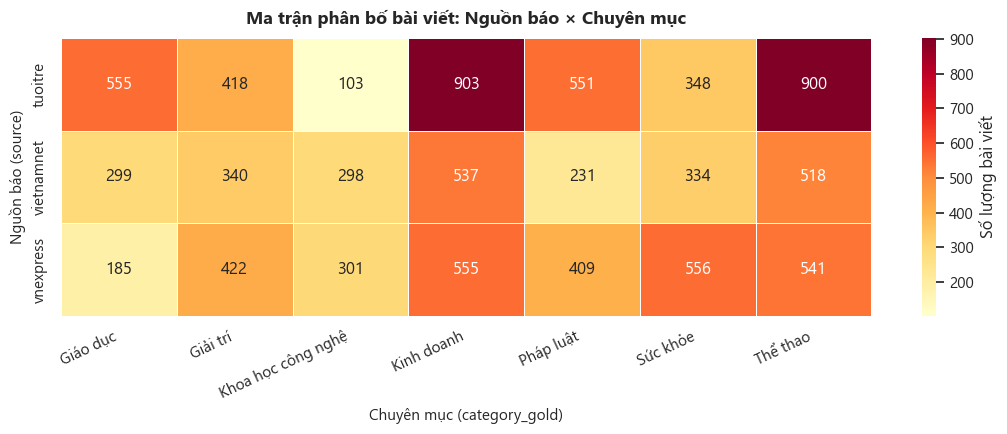

In [12]:
# Fig 3: heatmap_source_category
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlOrRd", ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Số lượng bài viết'})
ax.set_title("Ma trận phân bố bài viết: Nguồn báo × Chuyên mục", fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("Chuyên mục (category_gold)", fontsize=11)
ax.set_ylabel("Nguồn báo (source)", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_source_category.png", dpi=DPI)
plt.show()

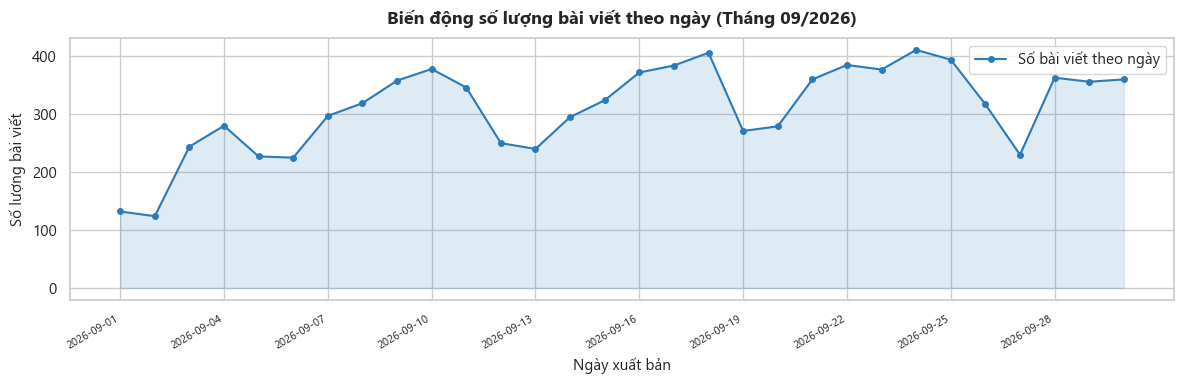

In [13]:
# Fig 4: line_daily_articles
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(daily)), daily["count"], marker="o", markersize=4, linewidth=1.5, color="#2b7bba", label="Số bài viết theo ngày")
ax.fill_between(range(len(daily)), daily["count"], alpha=0.15, color="#2b7bba")
step = max(1, len(daily) // 10)
ax.set_xticks(range(0, len(daily), step))
ax.set_xticklabels([str(daily["_date"].iloc[i]) for i in range(0, len(daily), step)],
                    rotation=30, ha="right", fontsize=8)
ax.set_title("Biến động số lượng bài viết theo ngày (Tháng 09/2026)", fontsize=13, pad=10, fontweight="bold")
ax.set_xlabel("Ngày xuất bản", fontsize=11)
ax.set_ylabel("Số lượng bài viết", fontsize=11)
ax.legend(loc="upper right", frameon=True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "line_daily_articles.png", dpi=DPI)
plt.show()

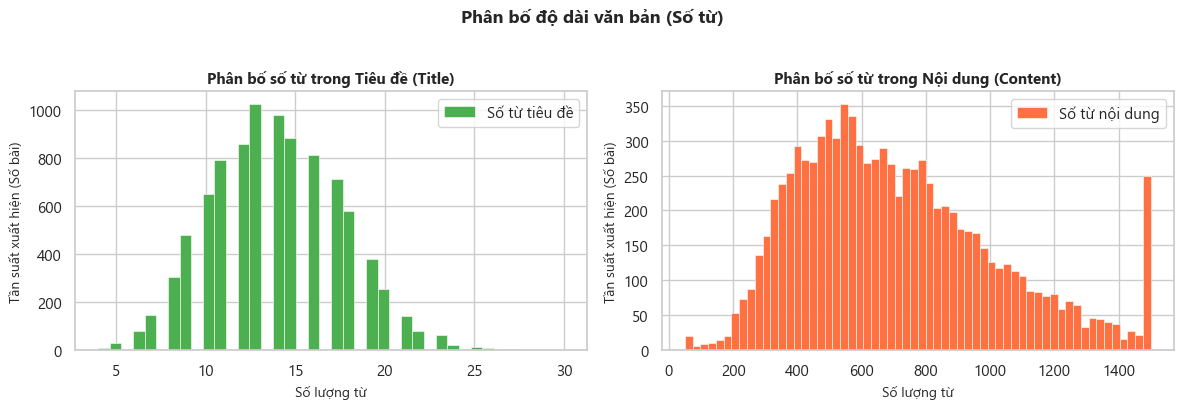

In [14]:
# Fig 5: hist_word_length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["_title_wc"].clip(upper=60), bins=40, color="#4caf50", edgecolor="white", linewidth=0.4, label="Số từ tiêu đề")
axes[0].set_title("Phân bố số từ trong Tiêu đề (Title)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Số lượng từ", fontsize=10)
axes[0].set_ylabel("Tần suất xuất hiện (Số bài)", fontsize=10)
axes[0].legend(loc="upper right", frameon=True)

axes[1].hist(df["_wc"].clip(upper=1500), bins=60, color="#ff7043", edgecolor="white", linewidth=0.4, label="Số từ nội dung")
axes[1].set_title("Phân bố số từ trong Nội dung (Content)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Số lượng từ", fontsize=10)
axes[1].set_ylabel("Tần suất xuất hiện (Số bài)", fontsize=10)
axes[1].legend(loc="upper right", frameon=True)

plt.suptitle("Phân bố độ dài văn bản (Số từ)", fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "hist_word_length.png", dpi=DPI)
plt.show()

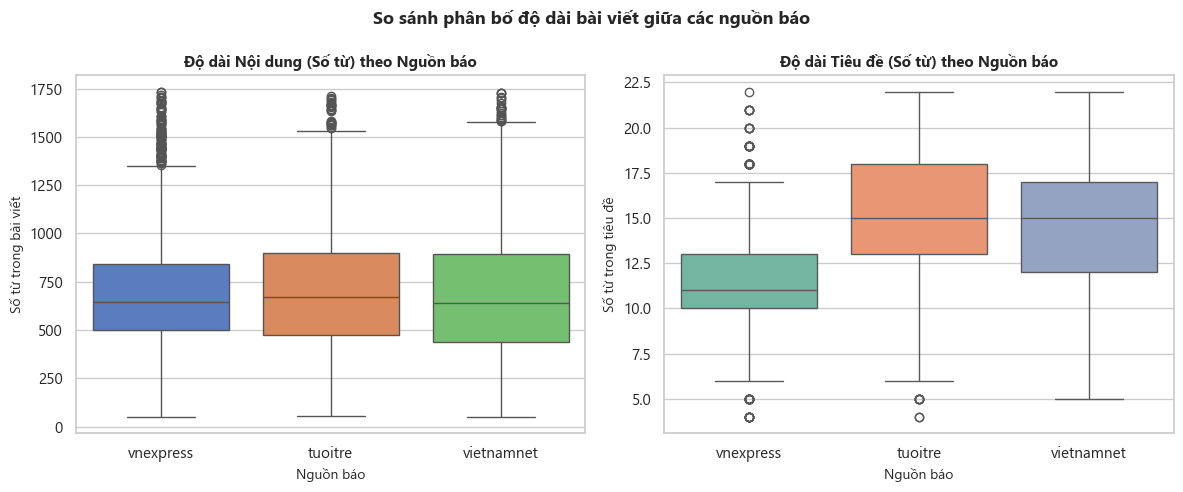

6 biểu đồ đã được hiển thị và lưu thành công vào results\data_quality\figures


In [15]:
# Fig 6: boxplot_length_by_source
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
p99c = df["_wc"].quantile(0.99)
p99t = df["_title_wc"].quantile(0.99)
sns.boxplot(data=df[df["_wc"] < p99c], x="source", y="_wc", ax=axes[0], palette="muted")
axes[0].set_title("Độ dài Nội dung (Số từ) theo Nguồn báo", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Nguồn báo", fontsize=10)
axes[0].set_ylabel("Số từ trong bài viết", fontsize=10)

sns.boxplot(data=df[df["_title_wc"] < p99t], x="source", y="_title_wc", ax=axes[1], palette="Set2")
axes[1].set_title("Độ dài Tiêu đề (Số từ) theo Nguồn báo", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Nguồn báo", fontsize=10)
axes[1].set_ylabel("Số từ trong tiêu đề", fontsize=10)

plt.suptitle("So sánh phân bố độ dài bài viết giữa các nguồn báo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "boxplot_length_by_source.png", dpi=DPI)
plt.show()
print("6 biểu đồ đã được hiển thị và lưu thành công vào", FIG_DIR.relative_to(ROOT))

## §5.4 EDA Tầng 3: Chất lượng Văn bản & Nhiễu

In [16]:
NOISE_PATTERNS = {
    "boilerplate_chia_se": "chia\\s+s\u1ebb",
    "boilerplate_theo_doi": "theo\\s+d\u00f5i",
    "boilerplate_xem_them": "xem\\s+th\u00eam",
    "boilerplate_quang_cao": "qu\u1ea3ng\\s+c\u00e1o",
    "boilerplate_doc_tiep": "\u0111\u1ecdc\\s+ti\u1ebfp",
    "markup_html_tags": "<.*?>",
    "markup_html_entities": "&amp;|&quot;|&lt;|&gt;|&nbsp;",
    "link_url": "https?://\\S+",
    "link_email": "\\S+@\\S+\\.\\S+",
    "media_caption": "(\u1ea2nh:|Video:|Ngu\u1ed3n:|\u0110\u1ed3 h\u1ecda:)",
}
noise_counts = {}
for key, pat in NOISE_PATTERNS.items():
    mask = df["content"].fillna("").str.contains(pat, regex=True, flags=re.IGNORECASE)
    n = int(mask.sum())
    noise_counts[key] = n
    qrow(f"noise.{key}", "regex_match", n, "INFO")

# Thu thập mẫu bản ghi chứa HTML tag (Task D01 deliverable)
for _, r in df[df["content"].fillna("").str.contains(r"<.*?>", regex=True)].iterrows():
    issues.append({
        "article_id": r["article_id"],
        "issue_type": "markup_html",
        "evidence": "Contains raw HTML tags",
        "action": "clean_in_p0"
    })

# Thu thập mẫu bản ghi chứa URL thô trong nội dung (Task D01 deliverable)
for _, r in df[df["content"].fillna("").str.contains(r"https?://\\S+", regex=True)].head(20).iterrows():
    issues.append({
        "article_id": r["article_id"],
        "issue_type": "inline_url",
        "evidence": "Contains raw URL in content",
        "action": "normalize_in_p1"
    })

title_in_content = df.apply(
    lambda r: str(r["title"]).strip().lower() in str(r["content"])[:500].lower()
              if pd.notna(r["title"]) and pd.notna(r["content"]) else False, axis=1)
n_title_repeat = int(title_in_content.sum())
noise_counts["title_repeat"] = n_title_repeat

noise_df = pd.DataFrame({"pattern": list(noise_counts.keys()), "count": list(noise_counts.values())})
display(noise_df.sort_values("count", ascending=False).reset_index(drop=True))
print(f"Đã thu thập {len([i for i in issues if i['issue_type'] in ['markup_html', 'inline_url']])} mẫu nhiễu HTML/URL vào danh sách issue_samples.")

,pattern,count
0,boilerplate_chia_se,1940
1,boilerplate_theo_doi,1263
2,media_caption,941
3,boilerplate_quang_cao,276
4,link_url,180
5,link_email,62
6,title_repeat,42
7,boilerplate_xem_them,21
8,boilerplate_doc_tiep,2
9,markup_html_tags,1


Đã thu thập 1 mẫu nhiễu HTML/URL vào danh sách issue_samples.


## §5.5 EDA Tầng 4: Trùng lặp & Rủi ro Rò rỉ Dữ liệu

In [17]:
url_exact_dup = int(df["url"].duplicated().sum())
df["_title_norm"] = df["title"].fillna("").str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
df["_content_norm"] = df["content"].fillna("").str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
title_exact_dup   = int(df["_title_norm"].duplicated().sum())
content_exact_dup = int(df["_content_norm"].duplicated().sum())
df["_title_stripped"] = df["_title_norm"].str.replace(r"[^\w\s]", "", regex=True).str.strip()
title_near_dup    = int(df["_title_stripped"].duplicated().sum())
leakage_risk = url_exact_dup + title_exact_dup + content_exact_dup

qrow("dup.url_exact","duplicated(url)",url_exact_dup,"PASS" if url_exact_dup==0 else "WARN")
qrow("dup.title_exact","duplicated(title_norm)",title_exact_dup,"PASS" if title_exact_dup==0 else "WARN")
qrow("dup.content_exact","duplicated(content_norm)",content_exact_dup,"PASS" if content_exact_dup==0 else "WARN")
qrow("dup.title_near","duplicated(title_stripped)",title_near_dup,"PASS" if title_near_dup==0 else "WARN")
qrow("leakage.risk_count","exact_dup_total",leakage_risk,"PASS" if leakage_risk==0 else "WARN")

# Thu thập toàn bộ bản ghi trùng lặp tiêu đề chính xác (Task D01 deliverable)
dup_title_mask = df["_title_norm"].duplicated(keep=False)
for _, r in df[dup_title_mask].iterrows():
    issues.append({
        "article_id": r["article_id"],
        "issue_type": "title_exact_duplicate",
        "evidence": str(r["title"])[:80],
        "action": "dedup_in_d02"
    })

# Thu thập bản ghi gần trùng lặp tiêu đề
dup_near_mask = df["_title_stripped"].duplicated(keep=False) & ~dup_title_mask
for _, r in df[dup_near_mask].iterrows():
    issues.append({
        "article_id": r["article_id"],
        "issue_type": "title_near_duplicate",
        "evidence": str(r["title"])[:80],
        "action": "dedup_in_d02"
    })

display(pd.DataFrame({
    "Loại trùng lặp": ["URL exact dup","Title exact dup","Content exact dup","Title near dup","Tổng nguy cơ rò rỉ (Leakage risk)"],
    "Số lượng": [url_exact_dup, title_exact_dup, content_exact_dup, title_near_dup, leakage_risk]
}))
print(f"Đã thu thập {dup_title_mask.sum()} bài trùng tiêu đề chính xác và {dup_near_mask.sum()} bài gần trùng vào danh sách issue_samples.")

,Loại trùng lặp,Số lượng
0,URL exact dup,0
1,Title exact dup,12
2,Content exact dup,0
3,Title near dup,13
4,Tổng nguy cơ rò rỉ (Leakage risk),12


Đã thu thập 23 bài trùng tiêu đề chính xác và 2 bài gần trùng vào danh sách issue_samples.


## §5.6 Lưu Deliverables & Xuất Báo cáo Tổng kết

In [ ]:
# 1. Lưu data_quality_summary.csv
pd.DataFrame(quality_rows).to_csv(RES_DQ/"data_quality_summary.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu data_quality_summary.csv ({len(quality_rows)} checks)")

# 2. Lưu issue_samples.csv (đảm bảo không bị rỗng, chứa đủ mẫu trùng tiêu đề & HTML/URL)
issues_df = pd.DataFrame(issues).drop_duplicates(subset=["article_id","issue_type"]).reset_index(drop=True)
issues_df.to_csv(RES_DQ/"issue_samples.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu issue_samples.csv ({len(issues_df)} bản ghi lỗi/nhiễu)")
display(issues_df["issue_type"].value_counts().to_frame("Số lượng mẫu"))
display(issues_df.head(10))

# 3. Lưu interim dataset news_articles_validated.csv
cols_drop = ["_wc","_title_wc","_title_cc","_content_cc","_date","_title_norm","_content_norm","_title_stripped"]
df.drop(columns=cols_drop, errors="ignore").to_csv(
    INTERIM/"news_articles_validated.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu news_articles_validated.csv ({len(df):,} bài viết)")

✓ Đã lưu data_quality_summary.csv (31 checks)
✓ Đã lưu issue_samples.csv (26 bản ghi lỗi/nhiễu)


,Số lượng mẫu
issue_type,
title_exact_duplicate,23
title_near_duplicate,2
markup_html,1


,article_id,issue_type,evidence,action
0,VNN_5125d50d6f97,markup_html,Contains raw HTML tags,clean_in_p0
1,VNN_6adc5075e331,title_exact_duplicate,"Giá bạc trong nước trái chiều, có loại giảm gầ...",dedup_in_d02
2,TTR_fbd4a3a200cc,title_exact_duplicate,APEC 2027: Cột mốc tạo động lực cho Cảng Hàng ...,dedup_in_d02
3,VNE_131f838b834b,title_exact_duplicate,Sun Life đẩy mạnh mở rộng mạng lưới tại Việt Nam,dedup_in_d02
4,VNN_621236c4d00c,title_exact_duplicate,Sun Life đẩy mạnh mở rộng mạng lưới tại Việt Nam,dedup_in_d02
5,VNE_03e8594cb5a7,title_exact_duplicate,"Giá xăng, dầu cùng tăng",dedup_in_d02
6,VNN_4de91baec3b9,title_exact_duplicate,APEC 2027: Cột mốc tạo động lực cho Cảng Hàng ...,dedup_in_d02
7,VNN_fd15fbdb95f4,title_exact_duplicate,Cựu Trưởng Công an Phú Quốc bị đề nghị 14-16 n...,dedup_in_d02
8,VNE_caee9f2e1b46,title_exact_duplicate,Cựu trưởng Công an Phú Quốc bị đề nghị 14-16 n...,dedup_in_d02
9,VNN_bd9bdce85826,title_exact_duplicate,Vietjet tổ chức chuỗi Ngày hội tuyển dụng tiếp...,dedup_in_d02


✓ Đã lưu news_articles_validated.csv (9,304 bài viết)


In [19]:
fail_checks = [r for r in quality_rows if r["status"] == "FAIL"]
warn_checks = [r for r in quality_rows if r["status"] == "WARN"]
if early_stop or fail_checks: exit_status = "FAIL"
elif warn_checks: exit_status = "PASS_WITH_WARNINGS"
else: exit_status = "PASS"

print(f"{'='*50}")
print(f"  KẾT LUẬN NGHIỆM THU (EXIT STATUS): {exit_status}")
print(f"  Số lỗi nghiêm trọng (FAIL): {len(fail_checks)}")
print(f"  Số cảnh báo (WARN)        : {len(warn_checks)}")
print(f"{'='*50}")

  KẾT LUẬN NGHIỆM THU (EXIT STATUS): PASS_WITH_WARNINGS
  Số lỗi nghiêm trọng (FAIL): 0
  Số cảnh báo (WARN)        : 3
